<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/Generic_Submerged_Object_Impact_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

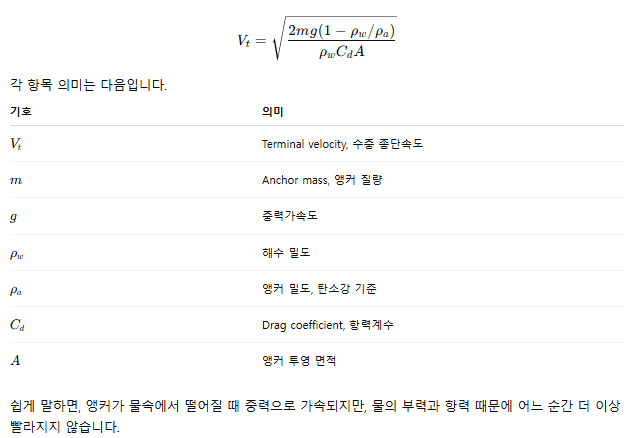

**Cable Impact Analysis_Terminal Velocity**

In [2]:
import math

# =========================================================
# Generic Submerged Object Motion Estimation
# =========================================================

# Environmental constants
FLUID_DENSITY = 1025.0      # Seawater density (kg/m^3)
OBJECT_DENSITY = 7850.0    # Representative metallic object density (kg/m^3)
GRAVITY = 9.81             # Gravity acceleration (m/s^2)

# Representative projected area (m^2)
REFERENCE_AREA = 0.2827


def estimate_motion_metrics(mass_kg, drag_coefficient):
    """
    Estimate terminal velocity and kinetic energy
    for a submerged generic object.

    Parameters
    ----------
    mass_kg : float
        Object mass [kg]

    drag_coefficient : float
        Hydrodynamic drag coefficient [-]

    Returns
    -------
    velocity : float
        Estimated terminal velocity [m/s]

    energy : float
        Estimated kinetic energy [J]
    """

    # Terminal velocity
    numerator = (
        2
        * mass_kg
        * GRAVITY
        * (1 - (FLUID_DENSITY / OBJECT_DENSITY))
    )

    denominator = (
        FLUID_DENSITY
        * drag_coefficient
        * REFERENCE_AREA
    )

    velocity = math.sqrt(numerator / denominator)

    # Kinetic energy
    energy = 0.5 * mass_kg * (velocity ** 2)

    return velocity, energy


# =========================================================
# Representative object classes
# =========================================================

object_classes = [
    {
        "class_name": "Object Class A",
        "mass_range": (10, 25)
    },
    {
        "class_name": "Object Class B",
        "mass_range": (30, 50)
    },
    {
        "class_name": "Object Class C",
        "mass_range": (60, 150)
    }
]

# Representative drag coefficients
drag_cases = [1.0, 0.8]

# =========================================================
# Result summary
# =========================================================

for obj in object_classes:

    min_mass, max_mass = obj["mass_range"]

    print(
        f"■ {obj['class_name']} "
        f"(Mass Range: {min_mass} ~ {max_mass} kg)"
    )

    for cd in drag_cases:

        min_v, min_e = estimate_motion_metrics(min_mass, cd)
        max_v, max_e = estimate_motion_metrics(max_mass, cd)

        print(f"  - Drag Coefficient Cd = {cd:.1f}")

        print(
            f"    Estimated Velocity [m/s] : "
            f"{min_v:.1f} ~ {max_v:.1f}"
        )

        print(
            f"    Estimated Energy [J]     : "
            f"{min_e:.0f} ~ {max_e:.0f}"
        )

    print("-" * 55)

■ Object Class A (Mass Range: 10 ~ 25 kg)
  - Drag Coefficient Cd = 1.0
    Estimated Velocity [m/s] : 0.8 ~ 1.2
    Estimated Energy [J]     : 3 ~ 18
  - Drag Coefficient Cd = 0.8
    Estimated Velocity [m/s] : 0.9 ~ 1.4
    Estimated Energy [J]     : 4 ~ 23
-------------------------------------------------------
■ Object Class B (Mass Range: 30 ~ 50 kg)
  - Drag Coefficient Cd = 1.0
    Estimated Velocity [m/s] : 1.3 ~ 1.7
    Estimated Energy [J]     : 26 ~ 74
  - Drag Coefficient Cd = 0.8
    Estimated Velocity [m/s] : 1.5 ~ 1.9
    Estimated Energy [J]     : 33 ~ 92
-------------------------------------------------------
■ Object Class C (Mass Range: 60 ~ 150 kg)
  - Drag Coefficient Cd = 1.0
    Estimated Velocity [m/s] : 1.9 ~ 3.0
    Estimated Energy [J]     : 106 ~ 662
  - Drag Coefficient Cd = 0.8
    Estimated Velocity [m/s] : 2.1 ~ 3.3
    Estimated Energy [J]     : 132 ~ 828
-------------------------------------------------------
